# Brock dataset 2 — automatic bout scoring from button-press events

The 20260622 session (s03/s04) has no hand-scored `ExpTrialBounds.mat`. Instead the
experimenter pressed the **event** sensor's button at the start and stop of every
movement bout, so the bounds live in the `.h5` `Annotations` stream ('Start'/'Stop').

Pipeline:

- **A. Events → snips** — `automatically_score_movements_from_events()` pairs Starts
  with Stops that occur within `BOUNDING_WINDOW_S`, reporting restarts (double-pressed
  Starts), orphan Stops, and suspiciously short pairs.
- **B. Condition table** — `load_condition_table()` parses the trialtable CSV and
  transcribes package size (ring=1, small=2, medium=3, large=4).
- **C. Compare to trials** — `compare_to_trials()` measures each snip's walked distance
  from the foot IMUs (single-foot mechanization, max horizontal excursion, best foot
  wins and names the walker), expands the table into the expected bout sequence
  (each trial × 2 reps × 2 walkers), and sequence-aligns measured vs expected distance
  so **missed / skipped trials fall out as unmatched expected bouts**.

NOTE: this session has only 3 foot IMUs (`left_foot_a` is absent), so subject-a bouts
are measured from the right foot alone.


In [1]:
# --- setup / configuration ---
%matplotlib inline
import sys, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath('.'))
sys.path.insert(0, os.path.abspath('src'))
import stride_imu as imu
from brock_functions import (load_events, automatically_score_movements_from_events,
                             load_condition_table, load_available_feet,
                             compare_to_trials, explain_missed, bout_spacing)

H5_FILE = os.environ.get('STRIDE_DATA_FILE',
    '/Users/jeremy/Dropbox/Treadmill Brock 2025/imu data/imuData_s03_s04_20260622.h5')
CONDITION_CSV = os.environ.get('STRIDE_TRIALTABLE_FILE',
    '/Users/jeremy/Dropbox/Treadmill Brock 2025/imu data/trialtable_20260622.csv')

BOUNDING_WINDOW_S = 30.0   # a Start and its Stop must fall within this window
MIN_BOUT_S = 1.5           # shorter pairs are flagged as likely accidental presses
pd.set_option('display.width', 160)


## A. Events → snips

Pair the button presses. The report shows every anomaly in the press stream:
`restarts` are Starts superseded by a later Start before any Stop (the bout keeps the
**last** Start), `orphan_stops` had no viable Start, and `short` flags sub-`MIN_BOUT_S`
pairs.


200 Starts + 183 Stops -> 180 snips
restarts (superseded Starts): 20 at t = [3274.8 3942.9 3989.9 5360.1 5518.5 5538.7 5599.3 5654.1 6395.6 6595.3
 7045.2 7240.9 7447.1 7516.2 8150.5 8176.8 8431.1 8498.4 8538.5 8707.4]
orphan Stops: [2855.9 4108.5 6495.2]
short (<1.5s) snips: [ 76 106 173] -> [[4105.2, 4106.2], [5838.5, 5839.8], [8549.0, 8549.8]]


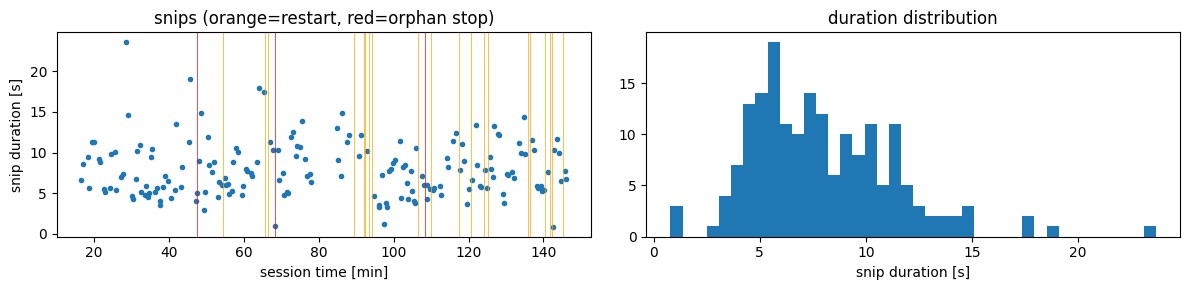

In [2]:
events = load_events(H5_FILE)
snips, report = automatically_score_movements_from_events(
    events, bounding_window_s=BOUNDING_WINDOW_S, min_bout_s=MIN_BOUT_S)

durations = snips[:, 1] - snips[:, 0]
print(f"{report['n_start']} Starts + {report['n_stop']} Stops -> {report['n_snips']} snips")
print(f"restarts (superseded Starts): {len(report['restarts'])} at t = {np.round(report['restarts'], 1)}")
print(f"orphan Stops: {np.round(report['orphan_stops'], 1)}")
print(f"short (<{MIN_BOUT_S}s) snips: {report['short']} -> {np.round(snips[report['short']], 1).tolist()}")

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(12, 3))
ax0.plot(snips[:, 0] / 60, durations, '.')
for t in report['restarts']:
    ax0.axvline(t / 60, color='orange', lw=0.5)
for t in report['orphan_stops']:
    ax0.axvline(t / 60, color='red', lw=0.5)
ax0.set_xlabel('session time [min]'); ax0.set_ylabel('snip duration [s]')
ax0.set_title('snips (orange=restart, red=orphan stop)')
ax1.hist(durations, bins=40)
ax1.set_xlabel('snip duration [s]'); ax1.set_title('duration distribution')
plt.tight_layout()


## B. Condition table

48 trials; `package_code` transcribes ring=1, small=2, medium=3, large=4. The rep
status columns carry the experimenter's notes (interruptions etc.) — useful when
interpreting alignment anomalies below.


In [3]:
conditions = load_condition_table(CONDITION_CSV)
print(conditions[conditions.rep1_status.ne('') | conditions.rep2_status.ne('')]
      [['trial', 'distance_m', 'package', 'rep1_status', 'rep2_status']].to_string(index=False))
conditions.head(8)


 trial  distance_m package                              rep1_status                                         rep2_status
     1         8.0   small                        trial interrupted                                                    
     7         2.5    ring        DID NOT  PAUSE SECOND PARTICIPANT                                                    
     9        12.0   large                                TWO STOPS PARTICIPANT VERIFYING ON WAY BACK PARTICIPANT A 12M
    12         5.0    ring         HELD WITH ONE HAND PARTICIPANT A                                                    
    20         5.0    ring                               WALKTHOUGH                                                    
    22        12.0   large                        LATE ON END EVENT                                                    
    25         2.5   small          DID NOT PAUSE FIRST PARTICIPANT                                                    
    29         8.0    ring    ONE ARM HO

,trial,rand,distance_m,package,pose,rep1_status,rep2_status,package_code
0,1,0.276,8.0,small,ground,trial interrupted,,2
1,2,0.475,5.0,medium,ground,,,3
2,3,0.905,12.0,medium,ground,,,3
3,4,0.697,5.0,small,held out,,,2
4,5,0.155,2.5,medium,waist,,,3
5,6,0.981,5.0,large,ground,,,4
6,7,0.944,2.5,ring,held out,DID NOT PAUSE SECOND PARTICIPANT,,1
7,8,0.025,8.0,small,held out,,,2


## C. Measure snip distances and compare to the trial table

This runs single-foot mechanization on every foot × snip (a few minutes). The
expected sequence is **rep-major** (confirmed against the data): the whole 48-trial
table is walked once (rep 1, 2 bouts per trial — one per walker), then again (rep 2).
The alignment tolerates extra snips and missing bouts.


In [4]:
feet = load_available_feet(H5_FILE)
print('feet available:', list(feet), f'@ {1/next(iter(feet.values())).period:.0f} Hz')
# drop the flagged sub-MIN_BOUT_S pairs (accidental presses) before aligning
snips_ok = np.delete(snips, report['short'], axis=0)
res = compare_to_trials(feet, snips_ok, conditions)
aligned = res['aligned']
err = aligned['distance_error_m'].abs()
print(f"matched {aligned['snip'].notna().sum()}/{len(aligned)} expected bouts; "
      f"median |distance error| {err.median():.2f} m (95th pct {err.quantile(0.95):.2f} m)")


feet available: ['left_foot_a', 'right_foot_a', 'right_foot_b', 'left_foot_b'] @ 128 Hz


matched 175/192 expected bouts; median |distance error| 0.46 m (95th pct 1.56 m)


## D. Results — where were trials missed or skipped?

`missed` = expected bouts (trial/rep/walker-slot) with no matching snip.
`extra` = snips that matched no expected bout (aborted movements, stray presses).


In [5]:
print('--- MISSED expected bouts ---')
print(res['missed'][['trial', 'rep', 'bout', 'distance_m', 'package', 'status']]
      .to_string(index=False))
print()
print('--- EXTRA snips (matched no expected bout) ---')
print(res['extra'][['start_s', 'stop_s', 'duration_s', 'distance_m', 'walker']]
      .round(2).to_string(index=False))


--- MISSED expected bouts ---
 trial  rep  bout  distance_m package                                status
    29    1     1         8.0    ring ONE ARM HOLDING OUT BOTH PARTICIPANTS
    37    1     1        12.0  medium                                      
    37    1     2        12.0  medium                                      
    38    1     1        12.0    ring ONE ARM HOLDING OUT BOTH PARTICIPANTS
     6    2     1         5.0   large                                      
    15    2     1        12.0   large                                      
    18    2     1         5.0   large                                      
    23    2     1         2.5    ring                                      
    26    2     1         8.0    ring                                      
    30    2     1         5.0    ring                                      
    30    2     2         5.0    ring                                      
    37    2     1        12.0  medium                     

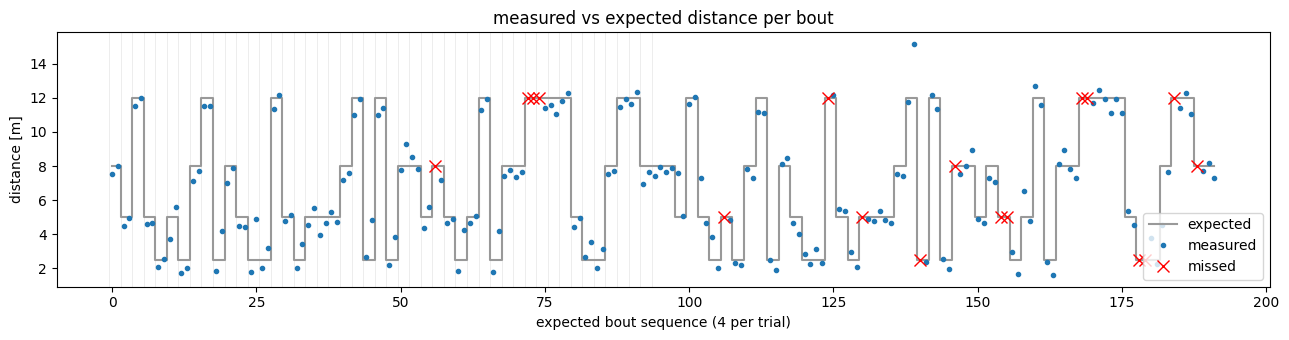

In [6]:
# measured vs expected distance over the aligned sequence
fig, ax = plt.subplots(figsize=(13, 3.5))
x = np.arange(len(aligned))
ax.step(x, aligned['distance_m'], where='mid', color='0.6', label='expected')
ax.plot(x, aligned['measured_m'], '.', label='measured')
miss = aligned['snip'].isna()
ax.plot(x[miss], aligned['distance_m'][miss], 'rx', ms=9, label='missed')
for t in aligned['trial'].unique():
    ax.axvline(aligned.index[aligned['trial'] == t][0] - 0.5, color='0.9', lw=0.5, zorder=0)
ax.set_xlabel('expected bout sequence (4 per trial)'); ax.set_ylabel('distance [m]')
ax.legend(); ax.set_title('measured vs expected distance per bout')
plt.tight_layout()


## E. The same picture across EXPERIMENT TIME, over the button presses

The sequence plot above hides *where the clicks were*. Here the x axis is real
experiment time (the top axis keeps the expected bout-sequence index / trial), and every
button press is drawn underneath: **Start = up tick, Stop = down tick** — direction as
well as colour, so identity never depends on colour alone. Grey = expected,
blue = measured, red X = missed. Only two annotation types exist in this file
(200 `Start`, 183 `Stop`, all from the `event` sensor) — there are no other button kinds.

Missed bouts have no snip, so each is placed at a time **interpolated** between its
matched neighbours. That is what makes the X readable against the press stream: if
presses sit under an X, the bout happened and the pairing/alignment rejected it; if the
band is empty under an X, the button was simply never pressed there.

**Pairing check (the 'uneven dots' flag):** each trial-rep should give exactly two bouts,
one per walker, at the same distance. The two are joined by a connector — **grey solid
when the pair is complete, red dashed when it is not**.


trial-reps not yielding a clean pair: 13
  trial  6 rep 2: 1 of 2 bouts matched
  trial 15 rep 2: 1 of 2 bouts matched
  trial 18 rep 2: 1 of 2 bouts matched
  trial 23 rep 2: 1 of 2 bouts matched
  trial 26 rep 2: 1 of 2 bouts matched
  trial 29 rep 1: 1 of 2 bouts matched
  trial 30 rep 2: 0 of 2 bouts matched
  trial 37 rep 1: 0 of 2 bouts matched
  trial 37 rep 2: 0 of 2 bouts matched
  trial 38 rep 1: 1 of 2 bouts matched
  trial 42 rep 2: 0 of 2 bouts matched
  trial 45 rep 2: 1 of 2 bouts matched
  trial 47 rep 2: 1 of 2 bouts matched


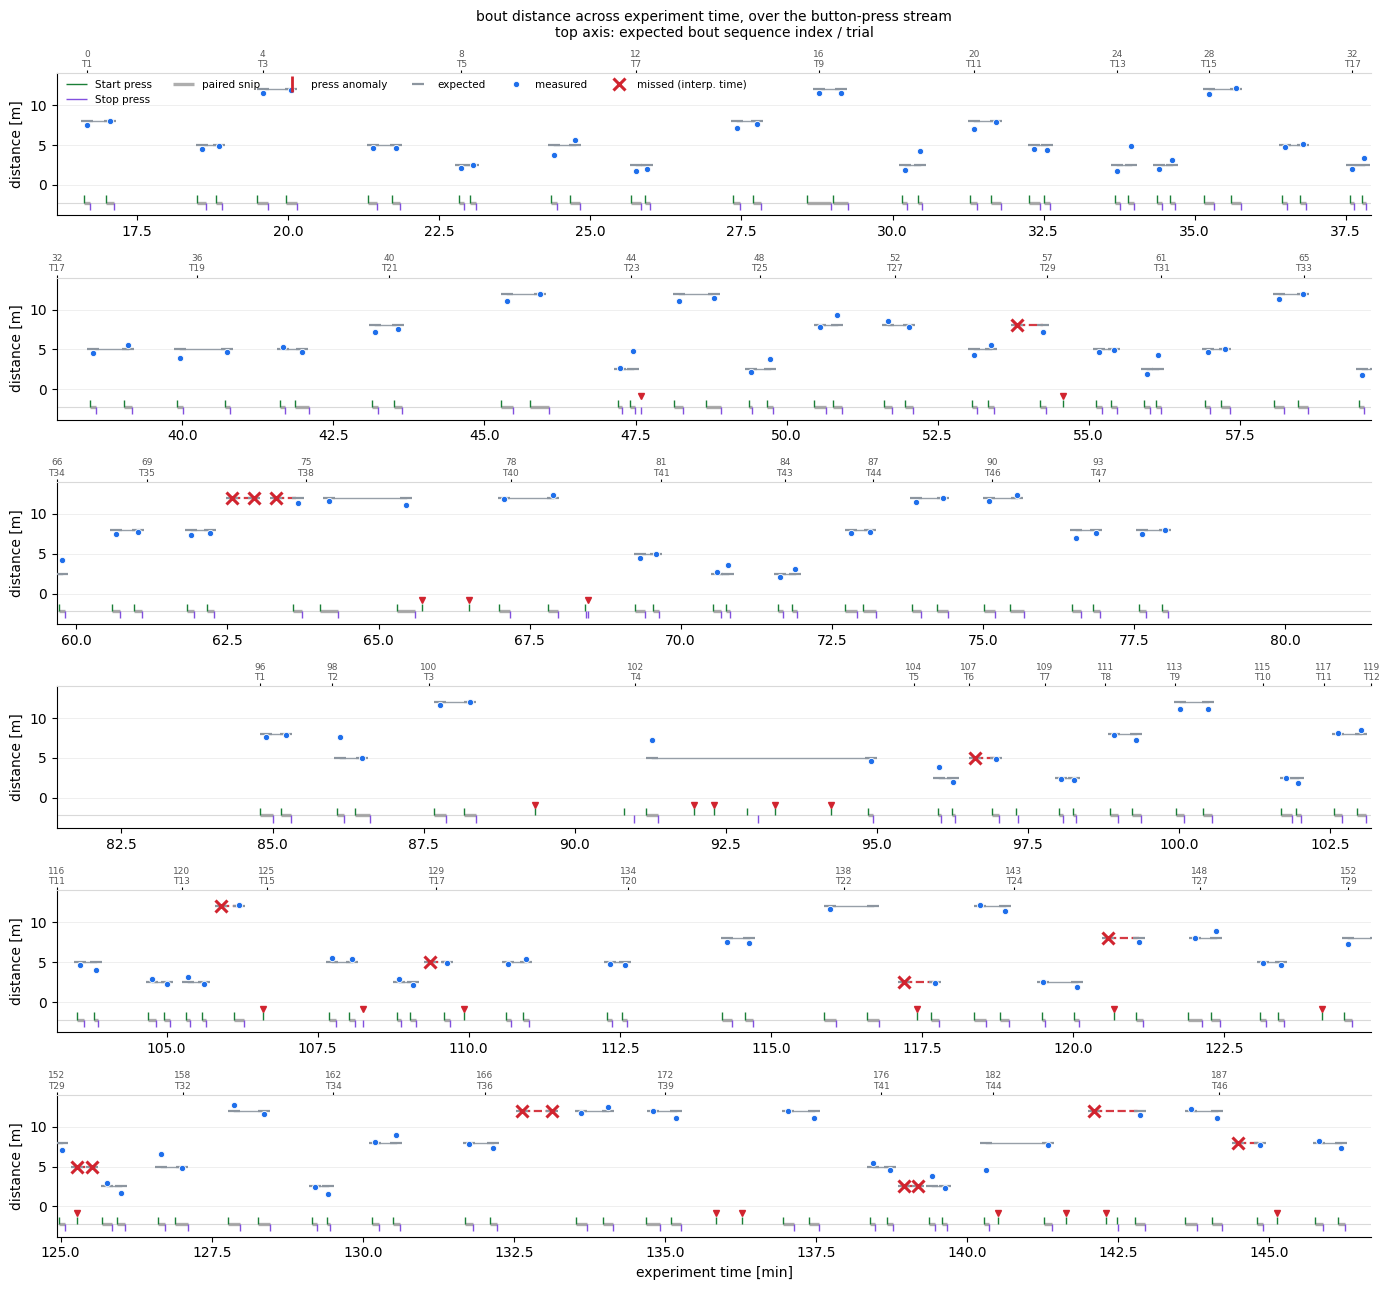

In [7]:
fig, axes = imu.draw_event_timeline(aligned, events, report, rows=6)

counts = imu.pair_status(aligned)
uneven = {k: v for k, v in counts.items() if v != 2}
print(f'trial-reps not yielding a clean pair: {len(uneven)}')
for (trial, rep), n in sorted(uneven.items()):
    print(f'  trial {trial:>2} rep {rep}: {n} of 2 bouts matched')


## F. Why is each bout missing? (documenting the logic)

`align_snips_to_expected()` is a **Needleman-Wunsch global alignment** on distance
alone: match cost = `|measured - expected| / max(...)`, while skipping either an expected
bout ('missed') or a measured snip ('extra') costs a flat `gap_penalty` (0.55). It
returns the single cheapest path through the cost matrix.

**Identifiability caveat — important.** Because distance is the only signal, within a run
of equal-distance trials the alignment recovers *how many* bouts are missing but **not
which ones**. Trials 37-40 rep 1 are all 12 m: the table below attributes the gap to
trial 37/38, but that is a traceback tie-break (ties drift gaps toward the start of a
run), not evidence. The defensible claim is *'3 of the 8 twelve-metre bouts across trials
37-40 rep 1 are missing'*. Run boundaries are firm only where the distance changes.

`explain_missed()` adds two signals the aligner never sees:

- **presses in the gap** — 0 means the button was never pressed there; an odd count means
  one press of a pair went missing.
- **room in the clock** — the gap length against the session's own between-trial pacing.
  A gap no longer than a normal transition has no room for an extra walk, so a red X
  there is more likely an alignment artifact than a genuinely missed bout.

**A test that did NOT work, recorded so it is not retried:** foot motion during the gap.
It looks decisive but is not — the participants walk *back* to the start between trials,
so control transition gaps contain a median **11.2 m** of walking versus **9.1 m** in the
suspect gaps. `walked_m` is reported for context only and is excluded from the verdict.


In [8]:
spacing = bout_spacing(aligned)
print(f"session pacing: {spacing['within_trial_s']:.0f} s between the two walkers of a rep, "
      f"{spacing['between_trial_s']:.0f} s between trials")

why = explain_missed(aligned, events, data=feet, spacing=spacing)
print(why[['trial', 'rep', 'bout', 'distance_m', 'gap_s', 'n_presses', 'presses',
           'walked_m', 'verdict']].round(1).to_string(index=False))
print()
print(why['verdict'].value_counts().to_string())


session pacing: 13 s between the two walkers of a rep, 46 s between trials


 trial  rep  bout  distance_m  gap_s  n_presses                presses  walked_m                                                verdict
    29    1     1         8.0   45.3          0                              9.1 no press, no room in clock - likely alignment artifact
    37    1     1        12.0   78.8          0                             13.1   no press + unexplained extra time - likely real miss
    37    1     2        12.0   78.8          0                             13.1   no press + unexplained extra time - likely real miss
    38    1     1        12.0   78.8          0                             13.1   no press + unexplained extra time - likely real miss
     6    2     1         5.0   36.6          0                              6.8 no press, no room in clock - likely alignment artifact
    15    2     1        12.0   27.6          0                             14.0 no press, no room in clock - likely alignment artifact
    18    2     1         5.0   28.6          0 

In [9]:
# save the aligned table alongside the other Brock outputs
aligned.to_csv('brock_dataset2_auto_aligned.csv', index=False)
print('wrote brock_dataset2_auto_aligned.csv,', len(aligned), 'rows')
aligned[aligned['snip'].isna() | aligned['distance_error_m'].abs().gt(1.5)]


wrote brock_dataset2_auto_aligned.csv, 192 rows


,trial,rep,bout,distance_m,package,package_code,status,snip,start_s,stop_s,duration_s,measured_m,walker,distance_error_m
19,10,1,2,2.5,medium,3,,19.0,1825.116015,1829.458018,4.342003,4.201141,right_foot_a,1.701141
25,13,1,2,2.5,large,4,,25.0,2033.961015,2039.887048,5.926033,4.872476,right_foot_a,2.372476
45,23,1,2,2.5,ring,1,,45.0,2844.697123,2849.724165,5.027042,4.856453,left_foot_b,2.356453
56,29,1,1,8.0,ring,1,ONE ARM HOLDING OUT BOTH PARTICIPANTS,NaN,NaN,NaN,NaN,NaN,,NaN
61,31,1,2,2.5,ring,1,,60.0,3366.453198,3371.387240,4.934042,4.262905,left_foot_a,1.762905
67,34,1,2,2.5,small,2,,66.0,3582.612252,3588.552300,5.940048,4.175594,right_foot_a,1.675594
72,37,1,1,12.0,medium,3,,NaN,NaN,NaN,NaN,NaN,,NaN
73,37,1,2,12.0,medium,3,,NaN,NaN,NaN,NaN,NaN,,NaN
74,38,1,1,12.0,ring,1,ONE ARM HOLDING OUT BOTH PARTICIPANTS,NaN,NaN,NaN,NaN,NaN,,NaN
98,2,2,1,5.0,medium,3,,94.0,5163.649426,5170.754428,7.105002,7.583883,right_foot_a,2.583883
